In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

### Inversionsmetoden – exponentialfördelning

In [2]:
u_samples = stats.uniform.rvs(size=10000)

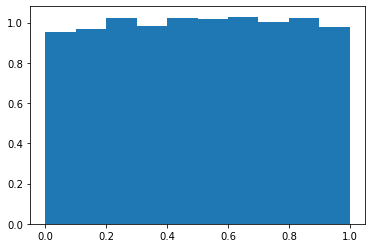

In [3]:
plt.hist(u_samples, density=True)
plt.show()

In [4]:
theta = 2

x_samples = -1 / theta * np.log(1 - u_samples)

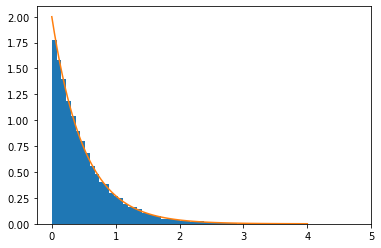

In [5]:
grid = np.linspace(0, 4, 100)
plt.hist(x_samples, density=True, bins=64)
plt.plot(grid, stats.expon.pdf(grid, scale=1 / theta))
plt.show()

### Inversionsmetoden – gammafördelning

In [6]:
def expon_sample(theta, size):
    u_samples = stats.uniform.rvs(size=size)
    x_samples = -1 / theta * np.log(u_samples)
    return x_samples

In [7]:
def gamma_sample(theta, n, size):
    x_samples = []
    for i in range(size):
        z_samples = expon_sample(theta, n)
        x_sample = np.sum(z_samples)
        x_samples.append(x_sample)
    return np.array(x_samples)

In [8]:
x_samples = gamma_sample(2, 7, 10000)

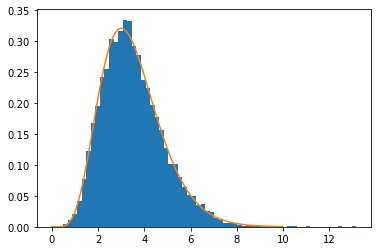

In [9]:
plt.hist(x_samples, density=True, bins=64)
grid = np.linspace(0, 10, 100)
plt.plot(grid, stats.gamma.pdf(grid, scale=1 / theta, a=7))
plt.show()

### Box–Muller-metoden

Vi vill generera ett stickprov av storlek $500$ från den simultana fördelningen $(X_1,X_2)$ där

$$
\begin{split}
X_1 &= N_1,\\
X_2 &= 2X_1 + N_2
\end{split}
$$

och $N_1$ och $N_2$ är oberoende och $N(0,1)$-fördelade. Vi gör det genom att generera ett stickprov från $N_1 = X_1$ med hjälp av Box–Muller metoden. Sedan för varje utfall $x_i$ i stickprovet genererar vi ett utfall $n_i$ från $N_2$ (med hjälp av Box–Muller metoden igen) och beräknar ett utfall från $f_{X_2 \mid X_1}(x_2 \mid x_1)$ genom formeln $x_2 = 2x_1 + n_1$.

Först definierar vi en funktion för Box–Muller metoden:

In [10]:
def box_muller(n):
    n_half = int(np.ceil(n / 2))

    u1 = stats.uniform.rvs(size=n_half)
    u2 = stats.uniform.rvs(size=n_half)

    radii = np.sqrt(-2 * np.log(u1))
    angles = 2 * np.pi * u2

    samples = np.concatenate(
        [
            [radius * np.cos(angle), radius * np.sin(angle)]
            for radius, angle in zip(radii, angles)
        ]
    )

    return samples[:n]

In [11]:
x_samples = box_muller(10000)

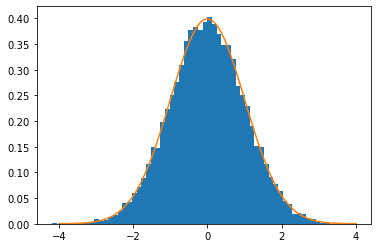

In [12]:
plt.hist(x_samples, density=True, bins=64)
grid = np.linspace(-4, 4, 100)
plt.plot(grid, stats.norm.pdf(grid))
plt.show()

Nu definierar vi en funktion som genererar ett stickprov av storlek $n$ från fördelningen $(X_1,X_2)$ där

$$
\begin{split}
X_1 &= N_1,\\
X_2 &= \lambda X_1 + N_2
\end{split}
$$

In [13]:
def sampler(n, λ):
    x1s = box_muller(n)
    n2s = box_muller(n)

    joint_samples = [[x1, λ * x1 + n2] for x1, n2 in zip(x1s, n2s)]

    return np.array(joint_samples)

När vi tar $\lambda = 2$ får vi önskat stickprov:

In [14]:
samples = sampler(500, 2)

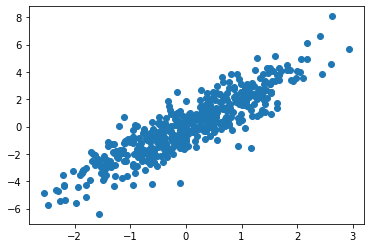

In [15]:
plt.scatter(samples[:, 0], samples[:, 1])
plt.show()

Här ser vi ett stickprov från fördelningen när $\lambda = -3$:

In [16]:
samples = sampler(500, -3)

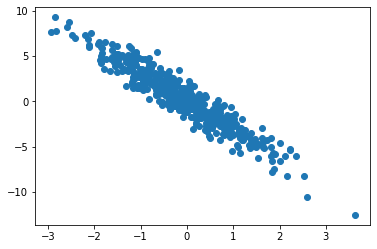

In [17]:
plt.scatter(samples[:, 0], samples[:, 1])
plt.show()

När vi tar $\lambda = 0$ har vi att $(X_1, X_2) = (N_1, N_2)$ där $N_1$ och $N_2$ är oberoende. Ett stickprov av storlek $500$ från denna population ser ut som följande:

In [18]:
samples = sampler(500, 0)

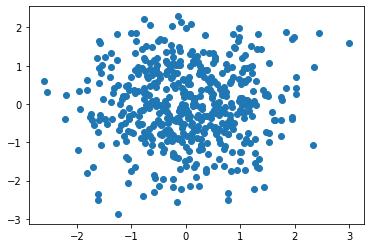

In [19]:
plt.scatter(samples[:, 0], samples[:, 1])
plt.show()

Plottarna visar att $\lambda$ kontrollerar _korrelationen_ mellan $X_1$ och $X_2$ vilket är ett beroendemått. Vi ser från formeln $X_2 = \lambda X_1 + N_1$ att $X_2$ är en linjär funktion av $X_1$ med lutningskoefficient $\lambda$.  När data följer en linje med en positiv lutningskoefficient säger vi att $X_1$ och $X_2$ är _positivt korrelerade_ och när den är negativ säger vi att de är _negativt korrelerade_. När koefficienten är lika med noll säger vi att de är _okorrelerade_.